## Importing Packages

In [1]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [3]:
year = 2025
race = "Belgian Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

core           INFO 	Loading data for Belgian Grand Prix - Race [v3.7.0]


req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '81'
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core       

## Load and Prepare Lap Data

In [4]:
laps = session.laps

laps = laps[[
    'Driver', 'LapNumber', 'LapTime',
    'Compound', 'TyreLife', 'Stint', 'Team'
]].dropna()

laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,Team,LapTimeSeconds
0,PIA,1.0,0 days 00:03:05.558000,INTERMEDIATE,1.0,1.0,McLaren,185.558
4,PIA,5.0,0 days 00:01:59.092000,INTERMEDIATE,5.0,1.0,McLaren,119.092
5,PIA,6.0,0 days 00:01:59.215000,INTERMEDIATE,6.0,1.0,McLaren,119.215
6,PIA,7.0,0 days 00:01:59.768000,INTERMEDIATE,7.0,1.0,McLaren,119.768
7,PIA,8.0,0 days 00:02:00.611000,INTERMEDIATE,8.0,1.0,McLaren,120.611


## Driver Comparison on Same Compound

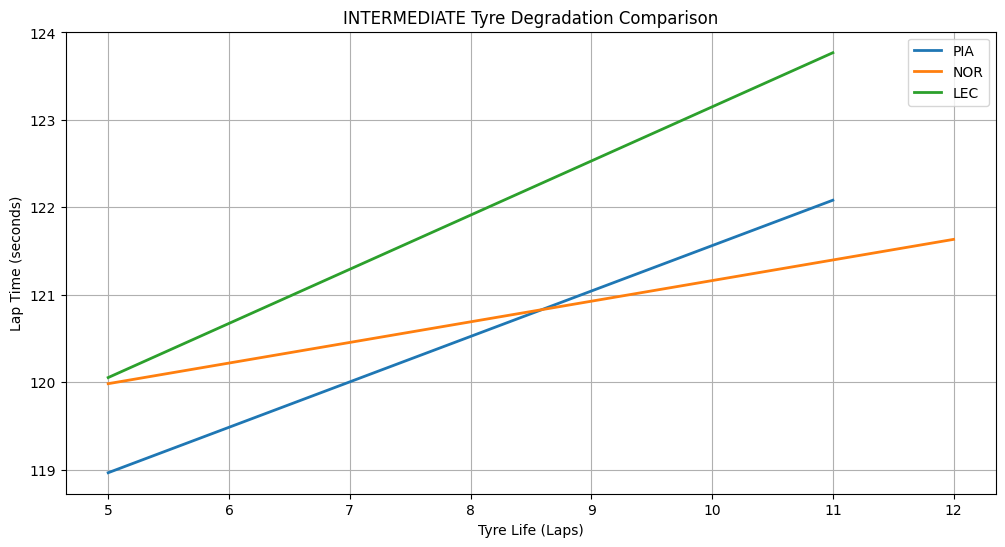

In [7]:
results = session.results

results = results.head(3)
drivers = results['Abbreviation']

# Get compounds used by each driver
driver_compounds = {
    drv: set(laps[laps['Driver'] == drv]['Compound'].unique())
    for drv in drivers
}

# Find intersection (common compounds)
common_compounds = set.intersection(*driver_compounds.values())

# Pick one (e.g., most frequent among common ones)
if common_compounds:
    compound_counts = laps[laps['Compound'].isin(common_compounds)]['Compound'].value_counts()
    compound = compound_counts.idxmax()
else:
    print("⚠️ No common compound found among top 3 drivers")
    compound = None

plt.figure(figsize=(12, 6))

for drv in drivers:
    data = laps[
        (laps['Driver'] == drv) &
        (laps['Compound'] == compound)
    ].copy()

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        print(f"⚠️ Skipping {drv} (no data)")
        continue

    if len(data) < 3:
        continue

    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=drv,
        linewidth=2
    )

plt.title(f"{compound} Tyre Degradation Comparison")
plt.xlabel("Tyre Life (Laps)")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True)

plt.show()

## Driver Comparison on Different Compound

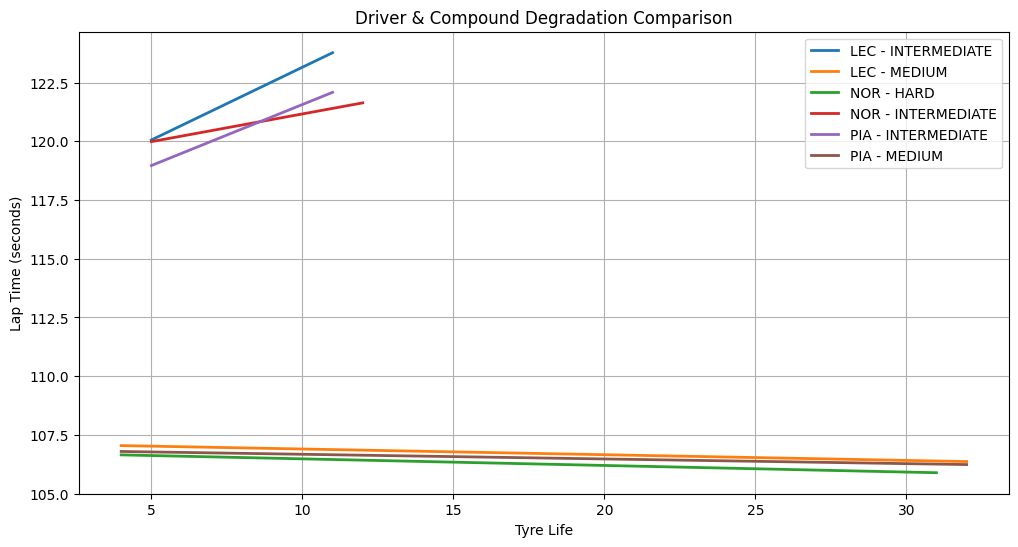

In [6]:
comparison = laps[laps['Driver'].isin(drivers)].copy()

plt.figure(figsize=(12, 6))

plotted = False

for (drv, comp), data in comparison.groupby(['Driver', 'Compound']):

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        continue

    data = data.sort_values('TyreLife')

    if len(data) < 3:
        continue

    # 🔧 Step 3: Use linear smoothing (IMPORTANT)
    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=f"{drv} - {comp}",
        linewidth=2
    )

    plotted = True

# ✅ Avoid legend warning
if plotted:
    plt.legend()

plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Driver & Compound Degradation Comparison")
plt.grid(True)

plt.show()